In [2]:
!pip install xgboost-cpu

  Obtaining dependency information for xgboost-cpu from https://files.pythonhosted.org/packages/cc/b6/3981ecd0f11992203254bb5a94002a6b07ada12d0e660f01f6e742d15795/xgboost_cpu-3.2.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
    --------------------------------------- 0.0/2.1 MB ? eta -:--:--
    --------------------------------------- 0.0/2.1 MB ? eta -:--:--
    --------------------------------------- 0.0/2.1 MB 393.8 kB/s eta 0:00:06
   - -------------------------------------- 0.1/2.1 MB 363.1 kB/s eta 0:00:06
   - -------------------------------------- 0.1/2.1 MB 403.5 kB/s eta 0:00:06
   -- ------------------------------------- 0.1/2.1 MB 481.4 kB/s eta 0:00:05
   --- ------------------------------------ 0.2/2.1 MB 551.6 kB/s eta 0:00:04
   ---- ----------------------------------- 0.2/2.1 MB 625.1 kB/s eta 0:00:04
   ----- ---------------------------------- 0.3/2.1 MB 707.1 kB/s eta 0:00:03
   ------ ------------------------


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Train Shape: (5634, 1175)
Test Shape: (1409, 1175)
Accuracy: 0.8537970191625266

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.70      0.72       374
           1       0.75      0.62      0.67        91
           2       0.90      0.94      0.92       944

    accuracy                           0.85      1409
   macro avg       0.80      0.75      0.77      1409
weighted avg       0.85      0.85      0.85      1409



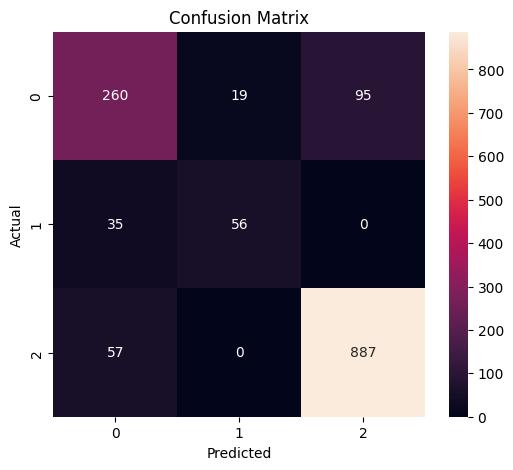

In [4]:
# ================================
# 1️⃣ Imports
# ================================
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
import xgboost as xgb

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# ================================
# 2️⃣ Load Train & Test CSV Files
# ================================
train_df = pd.read_csv("datasets/train_data.csv")
test_df = pd.read_csv("datasets/test_data.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)


# ================================
# 3️⃣ Separate Features & Target
# ================================
X_train = train_df.drop("Customer Status", axis=1)
y_train = train_df["Customer Status"]

X_test = test_df.drop("Customer Status", axis=1)
y_test = test_df["Customer Status"]


# ================================
# 4️⃣ Convert Categorical Columns
# ================================
# XGBoost requires category dtype

for col in X_train.select_dtypes(include="object").columns:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")


# ================================
# 5️⃣ Train XGBoost Model
# ================================
model = xgb.XGBClassifier(
    tree_method="hist",
    enable_categorical=True,
    random_state=42,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6
)

model.fit(X_train, y_train)


# ================================
# 6️⃣ Predictions
# ================================
y_pred = model.predict(X_test)


# ================================
# 7️⃣ Evaluation
# ================================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# ================================
# 8️⃣ Confusion Matrix
# ================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [13]:
# ======================================
# 1️⃣ Imports
# ======================================
import pandas as pd
import numpy as np
import xgboost as xgb

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score


# ======================================
# 2️⃣ Load Data
# ======================================
train_df = pd.read_csv("datasets/train_data.csv")
test_df = pd.read_csv("datasets/test_data.csv")

X_train = train_df.drop("Customer Status", axis=1)
y_train = train_df["Customer Status"]

X_test = test_df.drop("Customer Status", axis=1)
y_test = test_df["Customer Status"]


# ======================================
# 3️⃣ Convert Categorical Columns
# ======================================
for col in X_train.select_dtypes(include="object").columns:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")


# ======================================
# 4️⃣ Define Base Model
# ======================================
xgb_model = xgb.XGBClassifier(
    tree_method="hist",
    enable_categorical=True,
    random_state=42,
    objective="multi:softprob",
    eval_metric="mlogloss",
    n_jobs=4   # allow xgboost internal parallelism instead
)


# ======================================
# 5️⃣ Reduced Parameter Grid (Faster)
# ======================================
param_grid = {
    "n_estimators": [300],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
}


# ======================================
# 6️⃣ GridSearchCV (IMPORTANT CHANGE)
# ======================================
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    n_jobs=1     # 🔥 VERY IMPORTANT
)

grid_search.fit(X_train, y_train)


# ======================================
# 7️⃣ Best Model
# ======================================
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

best_model = grid_search.best_estimator_


# ======================================
# 8️⃣ Evaluate
# ======================================
y_pred = best_model.predict(X_test)

print("\nFinal Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=300; total time=   7.7s
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=300; total time=   9.7s
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=300; total time=  13.1s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=300; total time=  13.6s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=300; total time=  16.9s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=300; total time=  15.6s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=300; total time=  12.5s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=300; total time=  12.0s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=300; total time=  10.3s
[CV] END ...learning_rate=0.1, max_depth=6, n_estimators=300; total time=  10.0s
[CV] END ...learning_rate=0.1, max_depth=6, n_estimators=300; total time=   9.8s
[CV] END ...learning_rate=0.1, max_depth=6, n_est

In [14]:
import pickle

# Save model
with open("xgb_churn_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved successfully!")

Model saved successfully!


In [7]:
!pip install catboost

  Obtaining dependency information for catboost from https://files.pythonhosted.org/packages/a9/af/36048fdd08eca7876716176c30acf0e7ff1dfb1f53d0b93a021537e26601/catboost-1.2.10-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for graphviz from https://files.pythonhosted.org/packages/91/4c/e0ce1ef95d4000ebc1c11801f9b944fa5910ecc15b5e351865763d8657f8/graphviz-0.21-py3-none-any.whl.metadata
  Obtaining dependency information for plotly from https://files.pythonhosted.org/packages/8a/67/f95b5460f127840310d2187f916cf0023b5875c0717fdf893f71e1325e87/plotly-6.5.2-py3-none-any.whl.metadata
  Obtaining dependency information for narwhals>=1.15.1 from https://files.pythonhosted.org/packages/03/cc/7cb74758e6df95e0c4e1253f203b6dd7f348bf2f29cf89e9210a2416d535/narwhals-2.16.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   -------------------------------------


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# ======================================
# 1️⃣ Imports
# ======================================
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report


# ======================================
# 2️⃣ Load Data
# ======================================
train_df = pd.read_csv("datasets/train_data.csv")
test_df = pd.read_csv("datasets/test_data.csv")

X_train = train_df.drop("Customer Status", axis=1)
y_train = train_df["Customer Status"]

X_test = test_df.drop("Customer Status", axis=1)
y_test = test_df["Customer Status"]


# ======================================
# 3️⃣ Get Categorical Column Index
# ======================================
cat_features = X_train.select_dtypes(include="object").columns
cat_indices = [X_train.columns.get_loc(col) for col in cat_features]


# ======================================
# 4️⃣ Define Model
# ======================================
cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='MultiClass',  # use 'Logloss' if binary
    random_state=42,
    verbose=100
)


# ======================================
# 5️⃣ Train
# ======================================
cat_model.fit(X_train, y_train, cat_features=cat_indices)


# ======================================
# 6️⃣ Evaluate
# ======================================
y_pred = cat_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

0:	learn: 1.0467854	total: 182ms	remaining: 1m 31s
100:	learn: 0.3365118	total: 2.9s	remaining: 11.5s
200:	learn: 0.3091110	total: 5.47s	remaining: 8.14s
300:	learn: 0.2988911	total: 8.4s	remaining: 5.55s
400:	learn: 0.2919438	total: 11.6s	remaining: 2.86s
499:	learn: 0.2858129	total: 15.1s	remaining: 0us
Accuracy: 0.8608942512420156

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.70      0.73       374
           1       0.77      0.65      0.70        91
           2       0.90      0.94      0.92       944

    accuracy                           0.86      1409
   macro avg       0.81      0.76      0.78      1409
weighted avg       0.86      0.86      0.86      1409



In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(
    rf,
    param_grid,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    n_jobs=1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8459900638750887


In [10]:
print(y_test.value_counts(normalize=True))

Customer Status
2    0.669979
0    0.265436
1    0.064585
Name: proportion, dtype: float64


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.64      0.69       374
           1       0.80      0.54      0.64        91
           2       0.88      0.96      0.92       944

    accuracy                           0.85      1409
   macro avg       0.81      0.71      0.75      1409
weighted avg       0.84      0.85      0.84      1409



In [5]:
# ==========================================
# 1️⃣ Imports
# ==========================================
import pandas as pd
import numpy as np
import xgboost as xgb
import pickle

from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 2️⃣ Load Preprocessed Data
# ==========================================
train_df = pd.read_csv("datasets/train_data.csv")
test_df = pd.read_csv("datasets/test_data.csv")

# ==========================================
# 3️⃣ Split Features & Target
# ==========================================
target = "Customer Status"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

# ==========================================
# 4️⃣ Handle Class Imbalance
# ==========================================
scale = (len(y_train) - sum(y_train)) / sum(y_train)
print("Scale Pos Weight:", scale)

# ==========================================
# 5️⃣ Train Model
# ==========================================
model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================
# 6️⃣ Evaluate Model
# ==========================================
y_pred = model.predict(X_test)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred))

print("\n===== Confusion Matrix =====\n")
print(confusion_matrix(y_test, y_pred))

# ==========================================
# 7️⃣ Save Model + Columns
# ==========================================
pickle.dump(model, open("artifacts/xgb_churn_model.pkl", "wb"))
pickle.dump(X_train.columns.tolist(), open("artifacts/model_columns.pkl", "wb"))

print("\n✅ Model trained using preprocessed data!")

Scale Pos Weight: -0.2881869867340493


c:\Users\Vaishnavi\OneDrive\Desktop\Customer_Churn\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:04:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== Classification Report =====

              precision    recall  f1-score   support

           0       0.74      0.71      0.73       374
           1       0.74      0.64      0.69        91
           2       0.91      0.94      0.92       944

    accuracy                           0.86      1409
   macro avg       0.80      0.76      0.78      1409
weighted avg       0.86      0.86      0.86      1409


===== Confusion Matrix =====

[[267  20  87]
 [ 33  58   0]
 [ 59   0 885]]

✅ Model trained using preprocessed data!
